# KGW from Scratch: Embedding and Detecting Text Watermarks with DeepSeek

1. Implement KGW watermark embedding and detection from scratch.
2. Validate the implementation against Hugging Face's official version.
3. Use a short passage to demonstrate the watermark's qualitative effect.
4. Evaluate the algorithm on a larger experimental corpus.

Note: This notebook is designed to run on an NVIDIA A100 GPU.


In [1]:
# Colab already includes PyTorch, NumPy, Pandas, SciPy, scikit-learn, and Matplotlib.
%pip -q install "transformers==5.14.1" sacrebleu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 119.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.9/65.9 kB 6.5 MB/s eta 0:00:00


In [2]:
import json
import math
from functools import lru_cache
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from IPython.display import Markdown, display
from sacrebleu.metrics import CHRF
from scipy.stats import binom, gaussian_kde, norm
from sklearn.metrics import precision_score, recall_score, roc_auc_score
from transformers import (
    AutoModel, AutoModelForCausalLM, AutoTokenizer, LogitsProcessor,
    LogitsProcessorList, WatermarkDetector, WatermarkLogitsProcessor,
    WatermarkingConfig, set_seed,
)

CORPUS_URL = "https://raw.githubusercontent.com/GenTang/GenTang.github.io/main/content/en/blog/watermarking_on_aigc/data/kgw_corpus.jsonl"
SHOWCASE_URL = "https://raw.githubusercontent.com/GenTang/GenTang.github.io/main/content/en/blog/watermarking_on_aigc/data/kgw_showcase.jsonl"
MODEL_ID = "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B"

# KGW parameter: fraction of the vocabulary assigned to the green list.
GAMMA = 0.25
# Normal and extreme green-list biases.
NORMAL_DELTA, EXTREME_DELTA = 2.0, 8.0
# Public reproduction key and one-token context.
KEY, CONTEXT_WIDTH = 15_485_863, 1

# Evaluate prefixes containing 32, 64, 128, and 256 scored tokens.
PREFIXES = [32, 64, 128, 256]
# The theoretical threshold corresponds to a one-sided 1% FPR.
TARGET_FPR = 0.01
# Theoretical z-score threshold.
THEORETICAL_Z_THRESHOLD = float(norm.ppf(1 - TARGET_FPR))
SEED = 1024

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = (torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16) if DEVICE.type == "cuda" else torch.float32

# Load the main corpus and showcase separately so the showcase does not enter the statistical analysis.
data = pd.read_json(CORPUS_URL, lines=True)
showcase_original = pd.read_json(SHOWCASE_URL, lines=True).text.iloc[0]
print("Corpus passages:", len(data))

# Place the 1.5B model directly on the A100 and use PyTorch's efficient SDPA attention implementation.
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token_id is None:
    tokenizer.pad_token_id = tokenizer.eos_token_id
tokenizer.padding_side = "left"  # Decoder-only models require left padding for batched generation.
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, dtype=DTYPE, attn_implementation="sdpa"
).to(DEVICE).eval()
MODEL_DEVICE, VOCAB_SIZE = next(model.parameters()).device, model.config.vocab_size
print("Device:", MODEL_DEVICE, "dtype:", DTYPE, "vocabulary size:", VOCAB_SIZE)


Corpus passages: 1168


config.json:   0%|          | 0.00/679 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/3.07k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.55GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

Device: cuda:0 dtype: torch.bfloat16 vocabulary size: 151936


## 1. Embedding a KGW Watermark

Construct a random seed from the previous token and a secret key, then randomly permute the entire vocabulary. The first `gamma` fraction of tokens form the green list. Adding `delta` to their logits increases their sampling probability.

This notebook reproduces the `simple_1`/`lefthash` configuration used in the original paper, where `h=1`. The authors later recommended `selfhash + h=4` as a stronger private-watermark baseline.


In [3]:
class KGWLogitsProcessor(LogitsProcessor):
    """Apply the KGW green-list bias to model logits."""

    def __init__(
        self,
        vocab_size: int,
        device: torch.device | str,
        gamma: float = GAMMA,
        delta: float = NORMAL_DELTA,
        key: int = KEY,
    ) -> None:
        """
        Parameters
        ----------
        vocab_size : int
            Total number of tokens in the model vocabulary.
        device : str
            Device used to create the PyTorch random-number generator.
        gamma : float
            Fraction of the vocabulary assigned to the green list at each step.
        delta : float
            Bias added to green-list token logits.
        key : int
            Secret integer combined with the previous token to construct the random seed.
        """
        # Compute the green-list size only once during initialization.
        self.vocab_size, self.device = vocab_size, device
        self.green_size = int(vocab_size * gamma)
        self.delta, self.key = delta, key

    def greenlist(self, previous_token: int) -> torch.LongTensor:
        """Deterministically return green-list token IDs from the previous token and key."""
        # The embedding and detection sides must produce the same permutation for an identical previous_token and key.
        seed = (self.key * previous_token) % (2**64 - 1)
        generator = torch.Generator(device=self.device).manual_seed(seed)
        return torch.randperm(self.vocab_size, generator=generator, device=self.device)[:self.green_size]

    def __call__(
        self,
        input_ids: torch.LongTensor,
        scores: torch.FloatTensor,
    ) -> torch.FloatTensor:
        """Copy `scores` and add `delta` to each batch item's green-list logits."""
        # input_ids has shape (B, L).
        # scores has shape (B, V).
        # B is the batch size, L is the sequence length, and V is the vocabulary size.
        # Clone the tensor so other logits processors can still use the original input.
        scores = scores.clone()
        # Transfer all preceding tokens at once instead of synchronizing GPU to CPU per row.
        for row, previous_token in enumerate(input_ids[:, -1].tolist()):
            green_ids = self.greenlist(previous_token)
            scores[row, green_ids] += self.delta
        return scores

## 2. Detecting a KGW Watermark

Detection does not require model logits. At each position, reconstruct the green list and count the hits. Under the null hypothesis, if each position independently lands in the green list with probability `gamma`, then `G ~ Binomial(T, gamma)` and the test statistic is `z = (G - gamma*T) / sqrt(T*gamma*(1-gamma))`.


In [4]:
class KGWDetector:
    """Reconstruct KGW green lists and compute detection statistics."""

    def __init__(
        self,
        vocab_size: int,
        device: torch.device | str,
        gamma: float = GAMMA,
        key: int = KEY,
    ) -> None:
        """
        Parameters
        ----------
        vocab_size : int
            Total number of tokens in the model vocabulary.
        device : str
            Device used to reproduce the random permutation from generation.
        gamma : float
            Theoretical probability of a green-list hit under the null hypothesis.
        key : int
            Secret integer that must exactly match the generation-time key.
        """
        # Detector and embedder are independent, but must share vocab_size, gamma, key, and RNG device.
        self.vocab_size, self.device = vocab_size, device
        self.green_size = int(vocab_size * gamma)
        self.gamma, self.key = gamma, key

    @lru_cache(maxsize=256)
    def greenlist(self, previous_token: int) -> torch.LongTensor:
        """Return the green list for a preceding token and cache the 256 most recent results."""
        seed = (self.key * previous_token) % (2**64 - 1)
        generator = torch.Generator(device=self.device).manual_seed(seed)
        return torch.randperm(self.vocab_size, generator=generator, device=self.device)[:self.green_size]

    def __call__(
        self,
        token_ids: list[int] | torch.LongTensor,
    ) -> dict[str, int | float] | None:
        """Return the green count, z-score, and normal/binomial upper-tail probabilities."""
        # Convert to a flat Python list so each position's green list can be reconstructed.
        ids = torch.as_tensor(token_ids, device=self.device).flatten().tolist()
        if len(ids) <= CONTEXT_WIDTH:
            return None

        # Whether the current token is green depends on the token immediately before it.
        green = sum(current in self.greenlist(previous) for previous, current in zip(ids, ids[1:]))
        tokens = len(ids) - CONTEXT_WIDTH
        z = (green - self.gamma * tokens) / math.sqrt(tokens * self.gamma * (1 - self.gamma))
        return {
            "tokens": tokens, "green": green, "fraction": green / tokens, "z": z,
            "p_normal": float(norm.sf(z)),
            "p_binomial": float(binom.sf(green - 1, tokens, self.gamma)),
        }

## 3. Cross-validating Against Hugging Face

The validation has three levels: the green lists must match exactly, every element of the modified logits must match, and both detectors must return the same green-token count and z-score. Hugging Face's `p_value` uses an internal approximation, so it is not required to match the standard-normal tail probability exactly.


In [5]:
kgw = KGWLogitsProcessor(VOCAB_SIZE, MODEL_DEVICE)
ref = WatermarkLogitsProcessor(
    vocab_size=VOCAB_SIZE, device=str(MODEL_DEVICE), greenlist_ratio=GAMMA,
    bias=NORMAL_DELTA, hashing_key=KEY, seeding_scheme="lefthash", context_width=CONTEXT_WIDTH,
)

# Level 1: identical contexts must produce exactly the same green list.
context = torch.tensor([[101, 202], [303, 404]], device=MODEL_DEVICE)
assert torch.equal(kgw.greenlist(202), ref._get_greenlist_ids(context[0]))

# Level 2: after applying the bias, every element in the logits tensor must match.
scores = torch.randn(2, VOCAB_SIZE, device=MODEL_DEVICE)
torch.testing.assert_close(kgw(context, scores), ref(context, scores), rtol=0, atol=0)

# Level 3: for the same token sequence, both detectors must return the same hit count and z-score.
sequence = torch.tensor([[101, 202, 303, 404, 505, 606]], device=MODEL_DEVICE)
detector = KGWDetector(VOCAB_SIZE, MODEL_DEVICE)
z_score = detector(sequence[0])
ref_detector = WatermarkDetector(
    model.config, str(MODEL_DEVICE),
    WatermarkingConfig(greenlist_ratio=GAMMA, bias=NORMAL_DELTA, hashing_key=KEY,
                       seeding_scheme="lefthash", context_width=CONTEXT_WIDTH),
)
ref_z_score = ref_detector(sequence, return_dict=True)
assert z_score["green"] == int(ref_z_score.num_green_tokens[0])
np.testing.assert_allclose(z_score["z"], ref_z_score.z_score[0], rtol=1e-6)
print("Hugging Face cross-validation passed.")

Hugging Face cross-validation passed.


In [6]:
def is_watermarked(z_score: float, threshold: float) -> bool:
    """Return whether the z-score exceeds the specified watermark-detection threshold."""
    return z_score > threshold


def detect_ids(ids: list[int], threshold: float) -> dict:
    """Use all scorable tokens to determine whether the sequence contains this KGW watermark."""
    if len(ids) <= CONTEXT_WIDTH:
        return {"detected": False, "reason": "The text is too short to compute a KGW watermark score."}

    result = detector(ids)
    return {
        **result,
        "threshold": threshold,
        "detected": is_watermarked(result["z"], threshold),
    }


def detect_text(text: str, threshold: float) -> dict:
    """Tokenize plain text and use all scorable tokens to detect this KGW watermark."""
    ids = tokenizer(text, add_special_tokens=False).input_ids
    return detect_ids(ids, threshold)

## 4. Generating Paraphrases

The main experiment uses the faster DeepSeek-R1-Distill-Qwen-1.5B. We are studying watermarking rather than reasoning, so the prompt closes the `<think>` block. If the model enters a reasoning block again, retain only the original generated tokens after the final `</think>` tag.


In [7]:
THINK_OPEN_IDS = tokenizer("<think>", add_special_tokens=False).input_ids
THINK_CLOSE_IDS = tokenizer("</think>", add_special_tokens=False).input_ids
THINK_PREFILL_IDS = tokenizer("</think>\n", add_special_tokens=False).input_ids


def prompt_inputs(texts):
    """Construct a padded batch of R1 chat inputs and close each reasoning block."""
    conversations = []
    for text in texts:
        chars = len("".join(text.split()))
        content = (
            "Faithfully paraphrase the text below. Preserve all facts, "
            "logical relationships and conclusions, but rephrase using your own wording.\n"
            "Keep the output length roughly equal to the source text "
            f"(approximately {chars} non‑whitespace characters, ±10% tolerance is allowed).\n"
            "Do not add analysis or preamble. Output only the paraphrased text.\n\nSource text:\n" + text
        )
        conversations.append([{"role": "user", "content": content}])
    inputs = tokenizer.apply_chat_template(
        conversations, add_generation_prompt=True, tokenize=True, padding=True,
        return_dict=True, return_tensors="pt",
    )
    close = torch.tensor(THINK_PREFILL_IDS)[None].expand(len(texts), -1)
    inputs["input_ids"] = torch.cat([inputs["input_ids"], close], dim=1)
    inputs["attention_mask"] = torch.cat(
        [inputs["attention_mask"], torch.ones_like(close)], dim=1
    )
    return inputs.to(MODEL_DEVICE)


def find_last(ids: list[int], pattern: list[int]) -> int:
    """Return the start of the final complete pattern, or -1 if no match exists."""
    return next((i for i in range(len(ids) - len(pattern), -1, -1)
                 if ids[i:i + len(pattern)] == pattern), -1)


def body_tokens(ids: list[int]) -> tuple[list[int], bool]:
    """If R1 reasons again, retain only body tokens after the final `</think>`."""
    close = find_last(ids, THINK_CLOSE_IDS)
    if close >= 0:
        return ids[close + len(THINK_CLOSE_IDS):], True
    return ([], False) if find_last(ids, THINK_OPEN_IDS) >= 0 else (ids, True)


class GenerationNLLRecorder(LogitsProcessor):
    """Reuse raw generation logits to record the NLL of every generated token."""

    def __init__(self, model):
        self.current = self.previous = None
        self.steps = []
        # Capture raw logits before watermarking, temperature, and top-p transformations.
        self.hook = model.get_output_embeddings().register_forward_hook(self._capture)

    def _capture(self, module, inputs, output):
        self.current = output[:, -1].detach().clone()

    def _nll(self, token_ids):
        logits = self.previous.float()
        selected = logits.gather(1, token_ids[:, None]).squeeze(1)
        return torch.logsumexp(logits, dim=-1) - selected

    @torch.no_grad()
    def __call__(self, input_ids, scores):
        if self.previous is not None:
            self.steps.append(self._nll(input_ids[:, -1]))
        self.previous, self.current = self.current, None
        return scores

    def finish(self, sequences):
        """Record the final token and return token-aligned generation NLLs."""
        self.steps.append(self._nll(sequences[:, -1]))
        return torch.stack(self.steps, dim=1).cpu().tolist()

    def close(self):
        self.hook.remove()


@torch.inference_mode()
def generate_batch(texts, delta, seed=SEED):
    """Batch paraphrases at one KGW strength and record each body's mean base-model NLL."""
    set_seed(seed)
    inputs = prompt_inputs(texts)
    source_tokens = tokenizer(texts, add_special_tokens=False).input_ids
    kwargs = dict(
        do_sample=True, temperature=0.6, top_p=0.95,
        max_new_tokens=max(
            min(512, max(128, math.ceil(len(tokens) * 1.15)))
            for tokens in source_tokens
        ),
        pad_token_id=tokenizer.pad_token_id, eos_token_id=tokenizer.eos_token_id,
    )
    recorder = GenerationNLLRecorder(model)
    processors = [recorder]
    if delta:
        processors.append(KGWLogitsProcessor(VOCAB_SIZE, MODEL_DEVICE, delta=delta))
    kwargs["logits_processor"] = LogitsProcessorList(processors)

    try:
        sequences = model.generate(**inputs, **kwargs)
        token_nlls = recorder.finish(sequences)
    finally:
        recorder.close()
    outputs = sequences[:, inputs["input_ids"].shape[1]:].tolist()
    stop_ids = {tokenizer.eos_token_id, tokenizer.pad_token_id}
    result = []
    for output, nlls in zip(outputs, token_nlls):
        stop = next((i for i, token in enumerate(output) if token in stop_ids), len(output))
        output = output[:stop]
        output, valid = body_tokens(output)
        body_nlls = nlls[stop - len(output):stop] if output else []
        text_out = tokenizer.decode(output, skip_special_tokens=True).strip()
        result.append({
            "delta": delta, "seed": seed, "batch_size": len(texts),
            "text": text_out, "token_ids": output,
            "nll0": sum(body_nlls) / len(body_nlls) if body_nlls else None,
            "valid": valid and bool(text_out),
        })
    return result


def generate(text, delta, seed=SEED):
    """Single-item wrapper retained for the showcase."""
    return generate_batch([text], delta, seed)[0]

## 5. Qualitative Example and Text-quality Metrics

Generate unwatermarked, normally watermarked, and extremely watermarked paraphrases, then compare their text-quality metrics. The `showcase` is only a qualitative demonstration; it is not used for threshold calibration or AUC/FPR evaluation.


In [8]:
# Generate unwatermarked, normally watermarked, and extremely watermarked versions of the same passage.
SHOWCASE_MODES = {0.0: "unwatermarked", NORMAL_DELTA: "watermarked",
                  EXTREME_DELTA: "extreme_watermarked"}
showcase = [generate(showcase_original, delta) for delta in SHOWCASE_MODES]
if not all(item["valid"] for item in showcase):
    raise ValueError("The showcase contains unfinished reasoning or an empty body; change SEED and retry.")
display(Markdown("## Original\n" + showcase_original))
for item in showcase:
    display(Markdown(f"## {SHOWCASE_MODES[item['delta']]}\n" + item["text"]))

## Original
Compared with other books in the field, this book is distinctive in both its theoretical foundations and its engineering implementation.

- On the theoretical side, it draws on statistics, machine learning, econometrics, and related disciplines. Through carefully chosen analogies and lessons from classical models, it connects these fields and traces a coherent path from foundational models to large language models.

- On the engineering side, it goes beyond calling well-packaged third-party tools. Instead, it reimplements the core components of classical models so readers can understand their essential structures and key algorithms directly through code.

## unwatermarked
This book stands out in its theoretical depth and practical implementation, distinguishing itself from other works in its field. Its theoretical contributions span statistics, machine learning, and econometrics, drawing on foundational models and classical theories. It seamlessly integrates these disciplines, using carefully selected analogies and lessons from traditional models to weave them together cohesively. The narrative begins with basic models and progresses to advanced language models, illustrating the interconnectedness of these fields.

On the engineering side, the book goes beyond relying on third-party tools. Instead, it re-implements the core components of classical models, allowing readers to dissect their essential structures and key algorithms through code. This hands-on approach

## watermarked
This book uniquely combines its theoretical insights with practical implementation, making it a valuable resource for both students and professionals. It builds upon foundational statistical and machine learning models, integrating insights from classical economics and behavioral science, thereby creating a comprehensive framework. 

On the technical side, it goes beyond relying on third-party tools; it re-implements the core components of these models, allowing readers to dissect their structures and algorithms through code. This approach ensures a deep understanding for those seeking to apply these models effectively in their work.

Additionally, the book's focus on real-world applications in natural language processing (NLP) makes it highly practical. It provides readers with the tools and

## extreme_watermarked
Compared to other books in this technical field, the author provides distinct benefits in both its theoretical and applied sections.
Theoretical aspects:  

- It integrates foundational statistical models across machine learning, econometrics. It connects classical theory with machine-based approaches. It builds from basic algorithms through deep neural models.

Technologically innovative:  

- It goes beyond third-party solutions, re-implementing classical algorithms. It teaches by coding. It provides practical insights through open code snippets in both R, Python, and Java (sample Java code).

In [9]:
# Use the theoretical 1% FPR threshold to convert each z-score into a KGW-watermark decision.
showcase_detection = [{"mode": "original",
                       **detect_text(showcase_original, THEORETICAL_Z_THRESHOLD)}]
showcase_detection += [{"mode": SHOWCASE_MODES[item["delta"]],
                        **detect_ids(item["token_ids"], THEORETICAL_Z_THRESHOLD)}
                       for item in showcase]
display(pd.DataFrame(showcase_detection))

,mode,tokens,green,fraction,z,p_normal,p_binomial,threshold,detected
0,original,113,37,0.327434,1.900939,2.865500e-02,3.934065e-02,2.326348,False
1,unwatermarked,131,30,0.229008,-0.554877,7.105105e-01,7.408161e-01,2.326348,False
2,watermarked,131,62,0.473282,5.901869,1.797029e-09,2.764053e-08,2.326348,True
3,extreme_watermarked,106,99,0.933962,16.262392,9.123571e-60,8.290159e-51,2.326348,True


In [10]:
chrf = CHRF()
bge_tokenizer = AutoTokenizer.from_pretrained("BAAI/bge-small-zh-v1.5")
bge = AutoModel.from_pretrained("BAAI/bge-small-zh-v1.5").to(MODEL_DEVICE).eval()

@torch.inference_mode()
def embeddings(texts: list[str], batch_size: int = 32) -> torch.Tensor:
    """Compute normalized BGE sentence embeddings in batches and return a CPU tensor."""
    result = []
    for start in range(0, len(texts), batch_size):
        # Keep at most 512 embedding-model tokens to stay within the context window.
        batch = bge_tokenizer(texts[start:start + batch_size], padding=True, truncation=True,
                              max_length=512, return_tensors="pt").to(MODEL_DEVICE)
        result.append(F.normalize(bge(**batch).last_hidden_state[:, 0], dim=-1).cpu())
    return torch.cat(result)


def similarity(reference: str | list[str], candidate: str | list[str]) -> pd.DataFrame:
    """Compare reference and candidate passages.

    Higher chrF means greater character n-gram overlap; higher Semantic cosine means
    closer meaning; Length ratio is candidate tokens divided by reference tokens,
    and a value closer to 1 means more similar lengths.
    """
    references = [reference] if isinstance(reference, str) else reference
    candidates = [candidate] if isinstance(candidate, str) else candidate
    if len(references) == 1:
        references = references * len(candidates)
    reference_emb, candidate_emb = embeddings(references), embeddings(candidates)
    reference_ids = tokenizer(references, add_special_tokens=False).input_ids
    candidate_ids = tokenizer(candidates, add_special_tokens=False).input_ids
    return pd.DataFrame({
        "chrF": [chrf.sentence_score(c, [r]).score / 100 for r, c in zip(references, candidates)],
        "Semantic cosine": (reference_emb * candidate_emb).sum(dim=1).numpy(),
        "Length ratio": [len(c) / len(r) for r, c in zip(reference_ids, candidate_ids)],
    })


# In the showcase, the first comparison validates the metrics; the other two use the unwatermarked output as the baseline.
unwatermarked, watermarked, extreme_watermarked = showcase
comparisons = [
    ("Unwatermarked vs original", showcase_original, unwatermarked),
    ("Watermarked vs unwatermarked", unwatermarked["text"], watermarked),
    ("Extreme watermarked vs unwatermarked", unwatermarked["text"], extreme_watermarked),
]
for title, reference, candidate in comparisons:
    result = similarity(reference, candidate["text"])
    display(Markdown(f"### {title}"), result)

config.json:   0%|          | 0.00/776 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/367 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/110k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/439k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

...

,chrF,Semantic cosine,Length ratio
0,0.65272,0.959092,1.157895


### Watermarked vs unwatermarked

,chrF,Semantic cosine,Length ratio
0,0.548619,0.966058,1.0


### Extreme watermarked vs unwatermarked

,chrF,Semantic cosine,Length ratio
0,0.396885,0.934878,0.80303


## 6. Main Experiment

The detection threshold is fixed in advance at the one-sided 1% false-positive threshold of the standard normal distribution; no experimental data is used for calibration. Similar-length passages are generated in batches while their base-model NLL is recorded, and the final analysis reports FPR, TPR, and ROC-AUC.


In [11]:
# Set to 20 while debugging; None uses the full corpus.
MAX_SAMPLES = None
BATCH_SIZE = 200
sources = data.sample(frac=1, random_state=SEED).reset_index(drop=True)
if MAX_SAMPLES:
    sources = sources.head(MAX_SAMPLES).copy()
# Run the longest batch first so later, shorter batches can reuse allocated memory.
sources["source_tokens"] = [
    len(ids) for ids in tokenizer(sources["text"].tolist(), add_special_tokens=False).input_ids
]
sources = sources.sort_values("source_tokens", ascending=False).reset_index(drop=True)
print("Experimental passages:", len(sources))

# Batched sampling and NLL fields must not be mixed with old sequential-generation results.
RESULTS = Path(f"/content/kgw_r1_1_5b_batch{BATCH_SIZE}_nll_v2.jsonl")
records = [json.loads(line) for line in RESULTS.open(encoding="utf-8")] if RESULTS.exists() else []
done = {
    (int(row["source_id"]), float(row["delta"]))
    for row in records if row.get("valid", False) and row.get("nll0") is not None
}
tasks = [(source, delta) for source in sources.itertuples(index=False)
         for delta in (0.0, NORMAL_DELTA)]
completed = sum((int(source.id), float(delta)) in done for source, delta in tasks)
print(f"Total tasks: {len(tasks)}; completed: {completed}; remaining: {len(tasks) - completed}")

with RESULTS.open("a", encoding="utf-8") as output:
    for start in range(0, len(sources), BATCH_SIZE):
        batch = list(sources.iloc[start:start + BATCH_SIZE].itertuples(index=False))
        texts = [source.text for source in batch]
        # Use the same seed for unwatermarked and watermarked versions of one batch.
        for delta in (0.0, NORMAL_DELTA):
            pending_indices = [
                index for index, source in enumerate(batch)
                if (int(source.id), float(delta)) not in done
            ]
            if len(pending_indices) == 0:
                continue
            generated_batch = generate_batch(texts, delta, SEED)
            for index in pending_indices:
                source, item = batch[index], generated_batch[index]
                task = (int(source.id), float(delta))
                row = {"source_id": int(source.id), "source_text": source.text, **item}
                output.write(json.dumps(row, ensure_ascii=False) + "\n")
                output.flush()
                records.append(row)
                done.add(task)
                completed += 1
            if completed % 100 == 0:
                print(f"[{completed}/{len(tasks)}] saved", flush=True)

valid_records = [
    row for row in records if row.get("valid", False) and row.get("nll0") is not None
]
generated = pd.DataFrame(valid_records)
print(f"Valid generations: {len(valid_records)}; invalid: {len(records) - len(valid_records)}")

Experimental passages: 1168
Total tasks: 2336; completed: 0; remaining: 2336
[10/2336] saved
[20/2336] saved
[30/2336] saved
[40/2336] saved
[50/2336] saved
[60/2336] saved
[70/2336] saved
[80/2336] saved
[90/2336] saved
[100/2336] saved
[110/2336] saved
[120/2336] saved
[130/2336] saved
[140/2336] saved
[150/2336] saved
[160/2336] saved
[170/2336] saved
[180/2336] saved
[190/2336] saved
[200/2336] saved
[210/2336] saved
[220/2336] saved
[230/2336] saved
[240/2336] saved
[250/2336] saved
[260/2336] saved
[270/2336] saved
[280/2336] saved
[290/2336] saved
[300/2336] saved
[310/2336] saved
[320/2336] saved
[330/2336] saved
[340/2336] saved
[350/2336] saved
[360/2336] saved
[370/2336] saved
[380/2336] saved
[390/2336] saved
[400/2336] saved
[410/2336] saved
[420/2336] saved
[430/2336] saved
[440/2336] saved
[450/2336] saved
[460/2336] saved
[470/2336] saved
[480/2336] saved
[490/2336] saved
[500/2336] saved
[510/2336] saved
[520/2336] saved
[530/2336] saved
[540/2336] saved
[550/2336] sav

In [12]:
generated["mode"] = np.where(generated["delta"] == 0, "unwatermarked", "watermarked")
unwatermarked = generated[generated["mode"] == "unwatermarked"][["source_id", "text", "nll0"]]
watermarked = generated[generated["mode"] == "watermarked"][["source_id", "text", "nll0"]]
pairs = unwatermarked.merge(watermarked, on="source_id", suffixes=("_unwatermarked", "_watermarked"))

# The main experiment uses each source's unwatermarked output as the baseline for changes introduced by watermarking.
quality = similarity(pairs["text_unwatermarked"].tolist(), pairs["text_watermarked"].tolist())
# A positive value means KGW made the output less likely under the base model.
quality["Delta NLL"] = (
    pairs["nll0_watermarked"] - pairs["nll0_unwatermarked"]
).to_numpy()
display(quality.agg(["mean", "std"]).round(3))

,chrF,Semantic cosine,Length ratio
mean,0.538,0.933,1.878
std,0.138,0.069,10.289


## 7. Z-score Distributions and Detection Performance at Different Text Lengths

Under the unwatermarked null hypothesis, z-scores should approximately follow a standard normal distribution and remain largely stable as text length changes. For watermarked text, the z-score should increase with the cumulative prefix length. Detection always uses the theoretical one-sided 1% threshold, while ROC-AUC, FPR, and TPR are reported over all experimental samples.


,mode,length,samples,mean,std
0,original,32,1168,0.046,1.039
1,original,64,1142,0.087,1.074
2,original,128,517,0.172,1.198
3,original,256,62,0.640,1.324
4,unwatermarked,32,1132,0.809,1.025
5,unwatermarked,64,1108,0.627,0.988
6,unwatermarked,128,571,0.764,1.039
7,unwatermarked,256,52,0.958,1.368
8,watermarked,32,1152,2.793,0.959
9,watermarked,64,1108,3.423,1.140


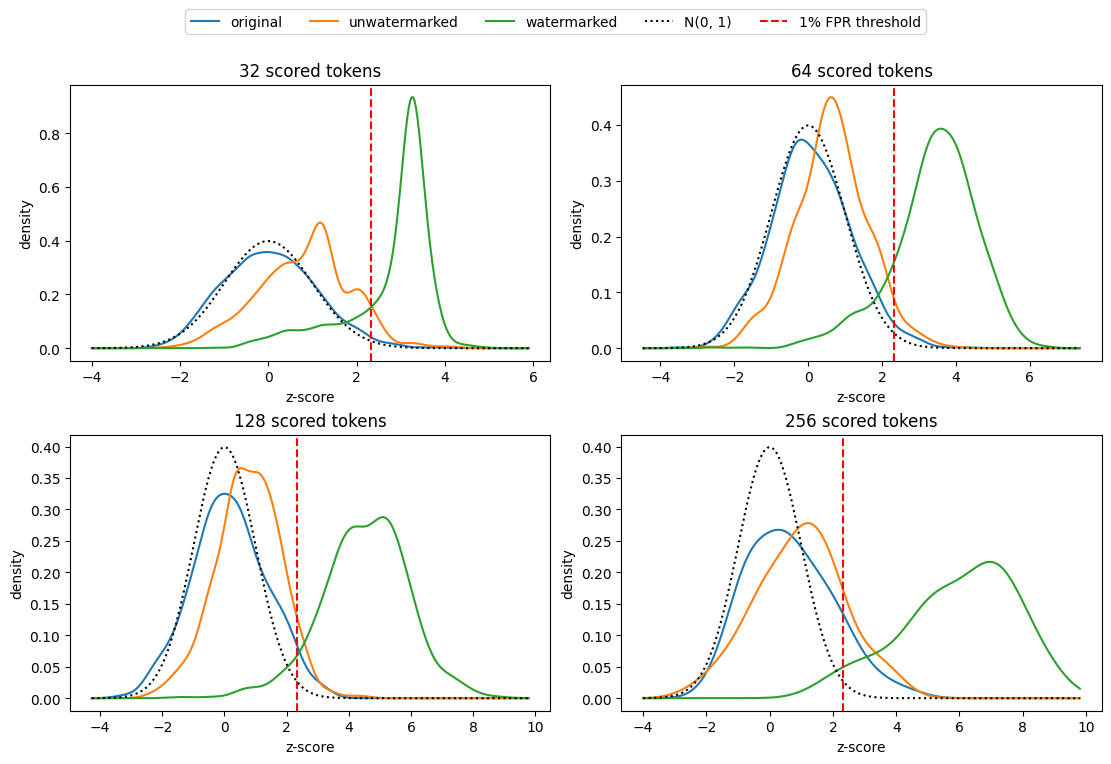

In [13]:
def prefix_z_scores(ids: list[int], source_id: int, mode: str) -> list[dict]:
    """Compute KGW z-scores at cumulative prefix lengths without making a watermark decision."""
    rows = []
    for length in PREFIXES:
        # The first token provides context; the following `length` tokens are scored.
        if len(ids) >= length + CONTEXT_WIDTH:
            rows.append({"source_id": source_id, "mode": mode, "length": length,
                         **detector(ids[:length + CONTEXT_WIDTH])})
    return rows


# Combine human originals, unwatermarked outputs, and watermarked outputs, then compute z-scores uniformly.
samples = [(source.id, "original", tokenizer(source.text, add_special_tokens=False).input_ids)
           for source in sources.itertuples(index=False)]
samples += [(row["source_id"], "unwatermarked" if row["delta"] == 0 else "watermarked",
             row["token_ids"]) for row in valid_records]
z_score_rows = [score for source_id, mode, ids in samples
              for score in prefix_z_scores(ids, source_id, mode)]

z_scores = pd.DataFrame(z_score_rows)

# Original and unwatermarked scores should approach N(0, 1); the watermarked mean should increase with length.
z_score_summary = (
    z_scores.groupby(["mode", "length"])["z"]
    .agg(samples="size", mean="mean", std="std")
    .reset_index()
)
display(z_score_summary.round(3))

# Plot distributions as the cumulative prefix grows: unwatermarked scores should remain stable,
# while watermarked scores should move toward larger z-scores. The red line is the theoretical 1% FPR threshold.
fig, axes = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True)
colors = {"original": "tab:blue", "unwatermarked": "tab:orange", "watermarked": "tab:green"}

for axis, length in zip(axes.flat, PREFIXES):
    part = z_scores[z_scores["length"] == length]
    x = np.linspace(min(-4, part["z"].min() - 1), max(4, part["z"].max() + 1), 300)
    for mode, color in colors.items():
        values = part.loc[part["mode"] == mode, "z"]
        if len(values) > 1 and values.std() > 0:
            axis.plot(x, gaussian_kde(values)(x), color=color, linewidth=1.5, label=mode)
    axis.plot(x, norm.pdf(x), "k:", label="N(0, 1)")
    axis.axvline(THEORETICAL_Z_THRESHOLD, color="red", linestyle="--", label="1% FPR threshold")
    axis.set(title=f"{length} scored tokens", xlabel="z-score", ylabel="density")

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.08), ncol=5)
plt.show()

In [14]:
# At each length, use all scorable text: original and unwatermarked are negative; watermarked is positive.
evaluation = []
for length, part in z_scores.groupby("length"):
    positive = part["mode"] == "watermarked"
    predicted = part["z"].map(lambda z: is_watermarked(z, THEORETICAL_Z_THRESHOLD))
    evaluation.append({
        "length": length,
        "neg_samples": (~positive).sum(),
        "pos_samples": positive.sum(),
        "ROC-AUC": roc_auc_score(positive, part["z"]),
        "Precision": precision_score(positive, predicted, zero_division=0),
        "Recall": recall_score(positive, predicted),
        "FPR": predicted[~positive].mean(),
    })

evaluation = pd.DataFrame(evaluation)
display(evaluation.round(3))

,length,neg_samples,pos_samples,ROC-AUC,Precision,Recall,FPR
0,32,2300,1152,0.932,0.906,0.799,0.042
1,64,2250,1108,0.967,0.942,0.834,0.025
2,128,1088,569,0.984,0.918,0.940,0.044
3,256,114,57,0.987,0.821,0.965,0.105
